# Network Analysis: Combined 2017-2019

This notebook analyzes the genre collaboration networks for all three years (2017-2019) in a unified workflow.

## Imports

In [1]:
import os
os.chdir('..') 
print("Now working from:", os.getcwd())

Now working from: /Users/mikolajandrzejewski/Documents/GitHub/Bachelor


In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [3]:
years = [2017, 2018, 2019]
dataframes = {}

for year in years:
    df = pd.read_csv(
        f"datasets/Original/global/global-genre_network-{year}.csv",
        sep="\t"
    )
    dataframes[year] = df


**Column descriptions:**
- source = first genre
- target = second genre
- weight = how many collaborations (co-appearances on charts)
- avg_streams = average streams for songs with this genre pair

## Collaboration Network Construction

In [4]:
networks = {}

for year in years:
    df = dataframes[year]
    G = nx.from_pandas_edgelist(
        df,
        source="source",
        target="target",
        edge_attr=["weight", "avg_streams"]
    )
    networks[year] = G
    print(f"{year}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

2017: 258 nodes, 2643 edges
2018: 295 nodes, 2856 edges
2019: 310 nodes, 2928 edges


## Network Overview

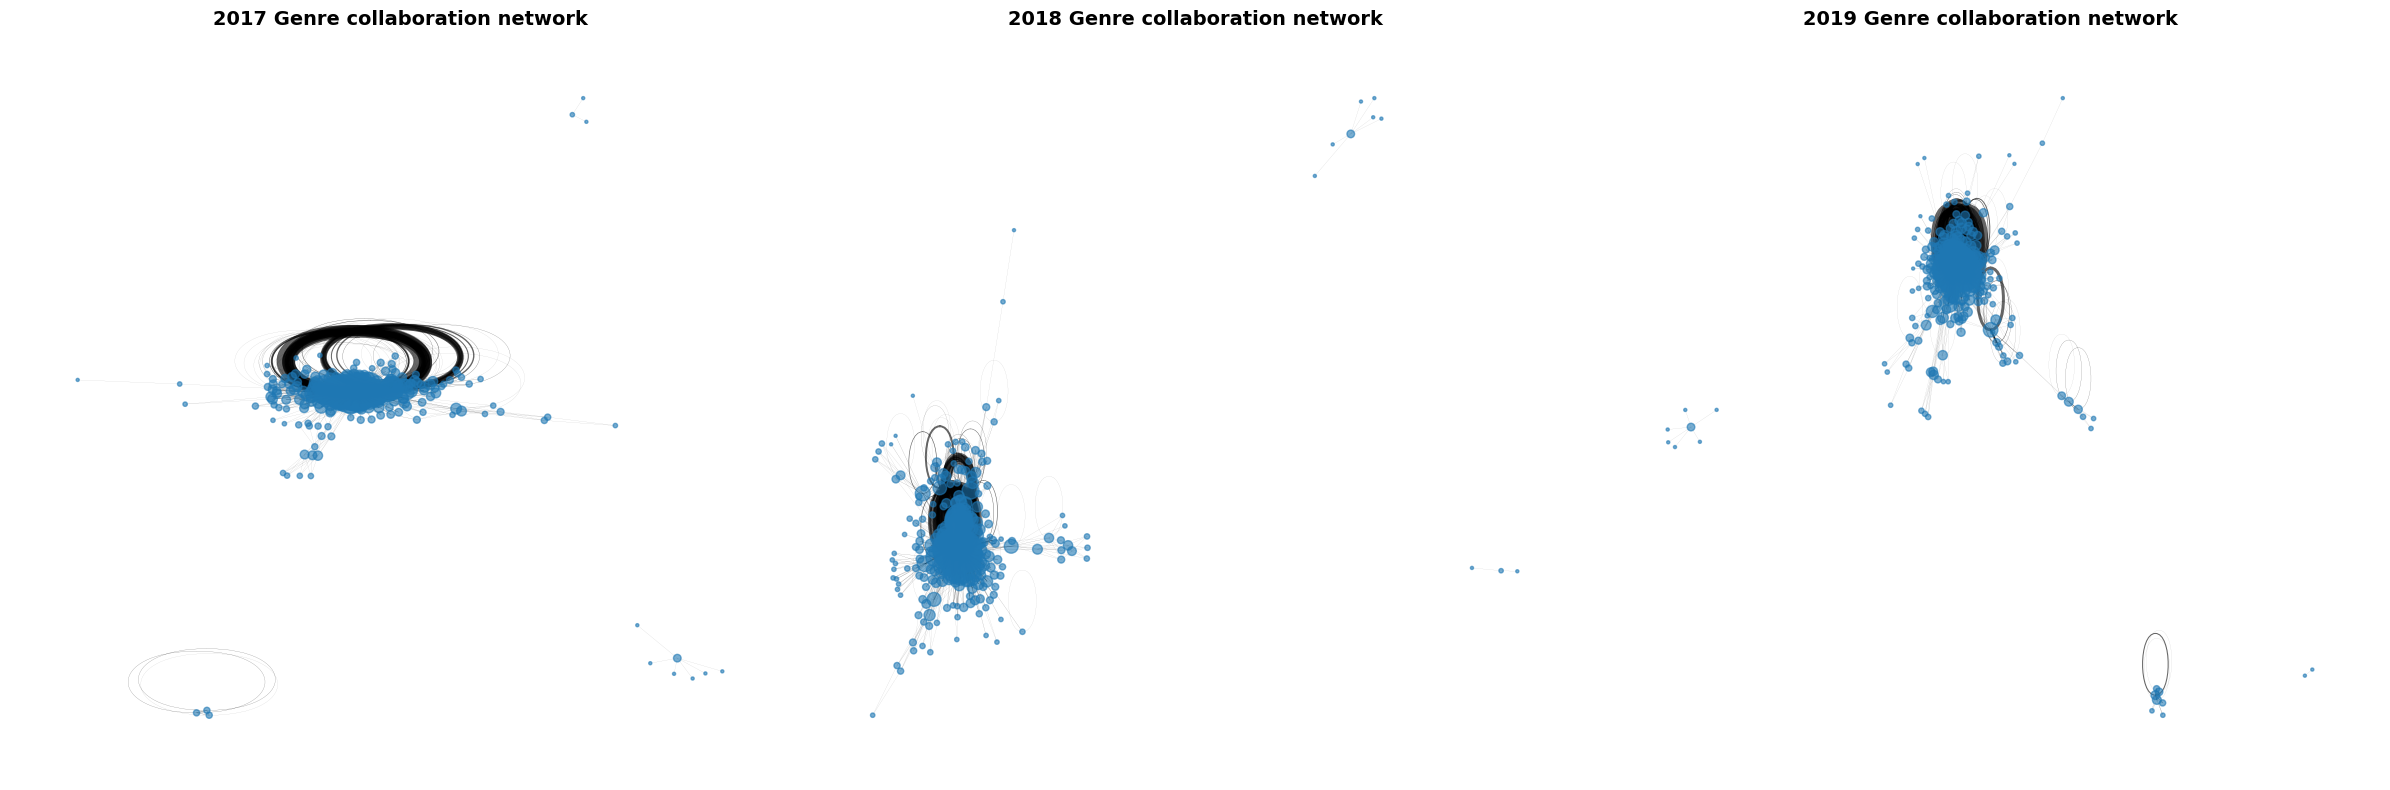

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for idx, year in enumerate(years):
    G = networks[year]
    ax = axes[idx]
    
    pos = nx.spring_layout(G, seed=42)
    
    node_sizes = [G.degree(n)*5 for n in G.nodes()]
    edge_widths = [G[u][v]["weight"]/20 for u,v in G.edges()]
    
    nx.draw(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        width=edge_widths,
        with_labels=False,
        alpha=0.6
    )
    
    ax.set_title(f"{year} Genre collaboration network", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# Network metrics
for year in years:
    G = networks[year]
    avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
    print(f"{year}: Average degree = {avg_degree:.2f}")

2017: Average degree = 20.49
2018: Average degree = 19.36
2019: Average degree = 18.89


## Network Structure Analysis

#### Node Degree Distribution

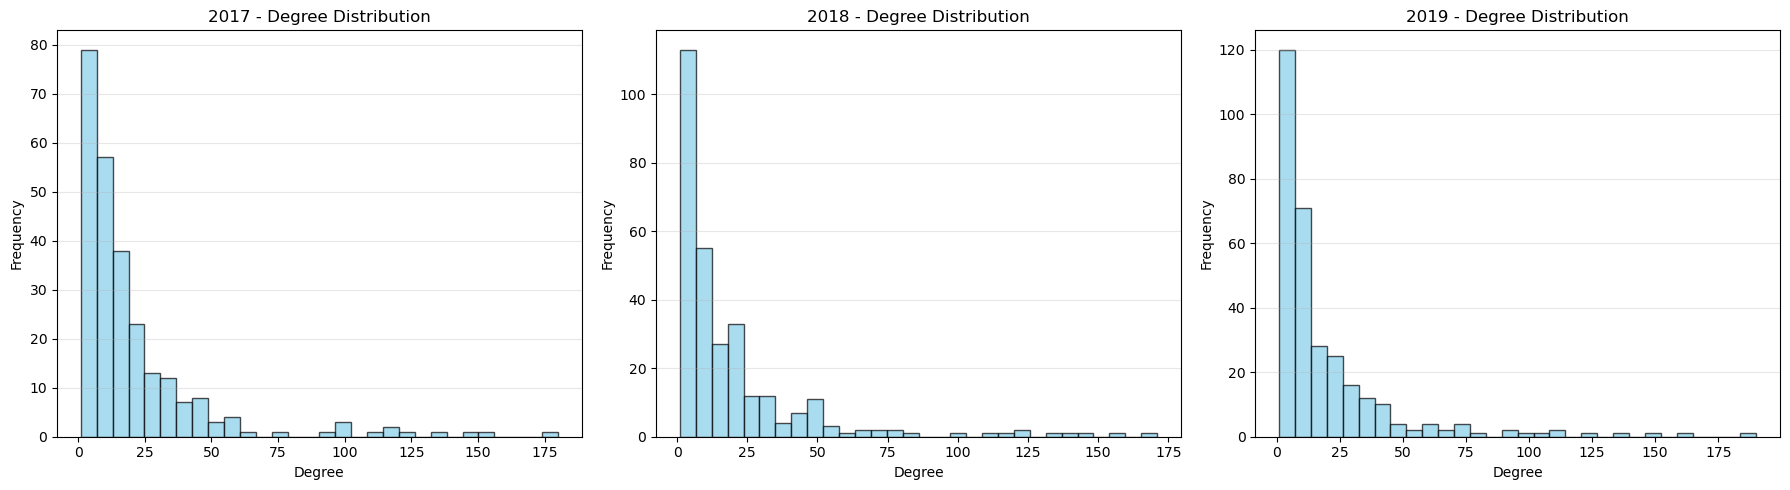

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, year in enumerate(years):
    G = networks[year]
    degrees = [deg for _, deg in G.degree()]
    
    ax = axes[idx]
    ax.hist(degrees, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Degree')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{year} - Degree Distribution')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Degree statistics
for year in years:
    G = networks[year]
    degrees = [deg for _, deg in G.degree()]
    print(f"\n{year} Degree Statistics:")
    print(pd.Series(degrees).describe())


2017 Degree Statistics:
count    258.000000
mean      20.488372
std       27.022434
min        1.000000
25%        5.000000
50%       11.000000
75%       23.750000
max      180.000000
dtype: float64

2018 Degree Statistics:
count    295.000000
mean      19.362712
std       26.603168
min        1.000000
25%        4.500000
50%       10.000000
75%       22.000000
max      171.000000
dtype: float64

2019 Degree Statistics:
count    310.000000
mean      18.890323
std       26.148584
min        1.000000
25%        5.000000
50%        9.000000
75%       21.000000
max      190.000000
dtype: float64


#### Edge Weight Distribution

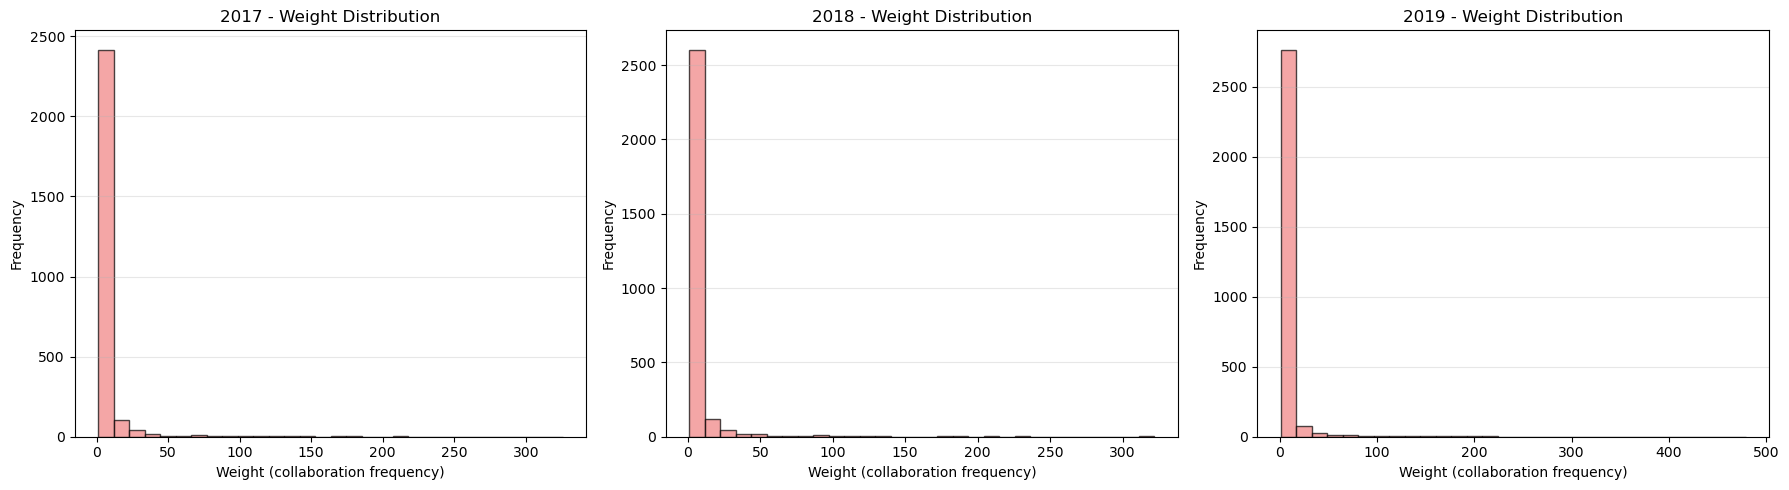

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, year in enumerate(years):
    G = networks[year]
    weights = [d["weight"] for _, _, d in G.edges(data=True)]
    
    ax = axes[idx]
    ax.hist(weights, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Weight (collaboration frequency)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{year} - Weight Distribution')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Most genre pairs occur very few times (1–3)

A small number of pairs occur a lot

In [10]:
for year in years:
    G = networks[year]
    weights = [d["weight"] for _, _, d in G.edges(data=True)]
    print(f"\n{year} Weight Statistics:")
    print(pd.Series(weights).describe())


2017 Weight Statistics:
count    2643.000000
mean        6.129777
std        20.089829
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       326.000000
dtype: float64

2018 Weight Statistics:
count    2856.000000
mean        6.225840
std        20.285056
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       322.000000
dtype: float64

2019 Weight Statistics:
count    2928.000000
mean        5.599044
std        19.253929
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       479.000000
dtype: float64


#### Popularity Distribution

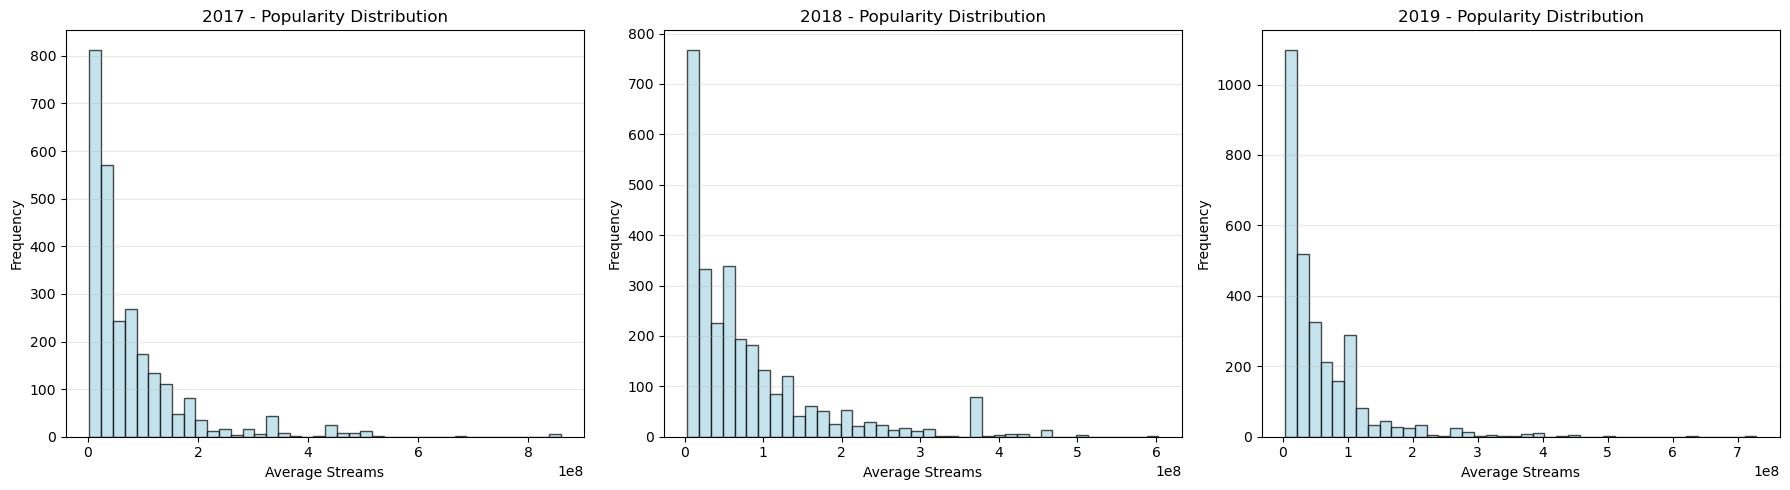

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, year in enumerate(years):
    G = networks[year]
    streams = [d["avg_streams"] for _, _, d in G.edges(data=True)]
    
    ax = axes[idx]
    ax.hist(streams, bins=40, color='lightblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Average Streams')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{year} - Popularity Distribution')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Even the least successful edges in this file are still quite successful (millions of streams)

(Selection bias: only chart-hitting songs are in the dataset)

In [19]:
for year in years:
    G = networks[year]
    streams = [d["avg_streams"] for _, _, d in G.edges(data=True)]
    print(f"\n{year} Streams Statistics:")
    print(pd.Series(streams).describe())


2017 Streams Statistics:
count    2.643000e+03
mean     7.661002e+07
std      9.757444e+07
min      2.598170e+06
25%      1.644437e+07
50%      4.194081e+07
75%      9.829979e+07
max      8.583335e+08
dtype: float64

2018 Streams Statistics:
count    2.856000e+03
mean     8.052020e+07
std      9.134964e+07
min      3.504950e+06
25%      1.531724e+07
50%      5.304020e+07
75%      1.050503e+08
max      6.032435e+08
dtype: float64

2019 Streams Statistics:
count    2.928000e+03
mean     5.619411e+07
std      6.677880e+07
min      4.104898e+06
25%      1.240201e+07
50%      3.295935e+07
75%      8.042885e+07
max      7.286733e+08
dtype: float64


## General Network Information

#### Top 10 genres with the highest collaboration count

In [13]:
for year in years:
    G = networks[year]
    top_genres = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]
    print(f"\n{'='*60}")
    print(f"{year} - Top 10 Genres by Collaboration Count")
    print(f"{'='*60}")
    for rank, (genre, degree) in enumerate(top_genres, 1):
        print(f"{rank:2d}. {genre:35s} - {degree:3d} collaborations")


2017 - Top 10 Genres by Collaboration Count
 1. pop                                 - 180 collaborations
 2. dance pop                           - 153 collaborations
 3. pop rap                             - 145 collaborations
 4. rap                                 - 135 collaborations
 5. tropical house                      - 125 collaborations
 6. hip hop                             - 118 collaborations
 7. edm                                 - 117 collaborations
 8. post-teen pop                       - 114 collaborations
 9. trap                                - 101 collaborations
10. southern hip hop                    -  97 collaborations

2018 - Top 10 Genres by Collaboration Count
 1. pop                                 - 171 collaborations
 2. dance pop                           - 158 collaborations
 3. rap                                 - 145 collaborations
 4. pop rap                             - 138 collaborations
 5. post-teen pop                       - 132 collaborat

#### Top 10 most frequently collaborating genres

In [14]:
for year in years:
    G = networks[year]
    top_edges = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:10]
    print(f"\n{'='*70}")
    print(f"{year} - Top 10 Most Frequent Genre Pairs")
    print(f"{'='*70}")
    for rank, (source, target, data) in enumerate(top_edges, 1):
        print(f"{rank:2d}. {source:25s} ↔ {target:25s} - {data['weight']:3d} times")


2017 - Top 10 Most Frequent Genre Pairs
 1. pop rap                   ↔ rap                       - 326 times
 2. rap                       ↔ trap                      - 268 times
 3. rap                       ↔ hip hop                   - 250 times
 4. pop rap                   ↔ trap                      - 236 times
 5. dance pop                 ↔ pop                       - 223 times
 6. pop rap                   ↔ pop                       - 216 times
 7. pop rap                   ↔ hip hop                   - 214 times
 8. rap                       ↔ pop                       - 207 times
 9. rap                       ↔ rap                       - 184 times
10. trap                      ↔ hip hop                   - 178 times

2018 - Top 10 Most Frequent Genre Pairs
 1. pop rap                   ↔ rap                       - 322 times
 2. rap                       ↔ trap                      - 312 times
 3. rap                       ↔ hip hop                   - 280 times
 4. lati

#### Top 10 most successful collaborations

In [20]:
for year in years:
    G = networks[year]
    top_edges = sorted(G.edges(data=True), key=lambda x: x[2]["avg_streams"], reverse=True)[:10]
    print(f"\n{'='*80}")
    print(f"{year} - Top 10 Most Successful Collaborations (by avg streams)")
    print(f"{'='*80}")
    for rank, (source, target, data) in enumerate(top_edges, 1):
        streams_millions = data['avg_streams'] / 1_000_000
        print(f"{rank:2d}. {source:25s} ↔ {target:25s} - {streams_millions:6.1f}M streams")


2017 - Top 10 Most Successful Collaborations (by avg streams)
 1. latin                     ↔ canadian pop              -  858.3M streams
 2. reggaeton                 ↔ canadian pop              -  858.3M streams
 3. tropical                  ↔ canadian pop              -  858.3M streams
 4. latin hip hop             ↔ canadian pop              -  858.3M streams
 5. canadian pop              ↔ latin pop                 -  858.3M streams
 6. canadian pop              ↔ puerto rican pop          -  858.3M streams
 7. electropop                ↔ permanent wave            -  666.1M streams
 8. hip hop                   ↔ dfw rap                   -  520.6M streams
 9. melodic rap               ↔ dfw rap                   -  520.6M streams
10. dance pop                 ↔ canadian contemporary r&b -  502.2M streams

2018 - Top 10 Most Successful Collaborations (by avg streams)
 1. tropical house            ↔ brostep                   -  603.2M streams
 2. canadian pop              ↔ vapor 

**Key observation:** Collaboration frequency is not equal to popularity

The most frequently collaborating genre pairs are not necessarily the most successful.